In [ ]:
import pandas as pd

# 1. Read the 'Long' sheet from the Excel file
file_path = '../data/Adolescent.xlsx'
df_long = pd.read_excel(file_path, sheet_name='Long')

# 2. Filter for target age group and core indicators
# Extract ANC4 (antenatal care 4+ visits), ORS (oral rehydration salts), CPMODHS (modern contraceptives) for ages 15-19
target_indicators = ['ANC4', 'ORS', 'CPMODHS']
df_filtered = df_long[
    (df_long['Age Group'] == '15-19 yrs') & 
    (df_long['Indicator'].isin(target_indicators))
]

# 3. Automatically extract the latest year data for each country-indicator pair
# Strategy: sort by country, indicator, and survey year (descending)
df_sorted = df_filtered.sort_values(
    by=['Country or Area', 'Indicator', 'Survey Year'], 
    ascending=[True, True, False]
)

# De-duplicate by country+indicator, keeping only the first row (latest year)
df_latest = df_sorted.drop_duplicates(subset=['Country or Area', 'Indicator'], keep='first')

# 4. Pivot from long to wide format (Wide Master Table)
df_wide = df_latest.pivot(
    index=['ISO', 'Country or Area'], 
    columns='Indicator', 
    values='Value (%)'
).reset_index()

# 5. Clean column names for readability
df_wide.columns.name = None
df_wide.rename(columns={
    'ANC4': 'ANC4_15_19_yrs(%)',
    'ORS': 'ORS_15_19_yrs(%)',
    'CPMODHS': 'CPMODHS_15_19_yrs(%)'
}, inplace=True)

display(df_wide.head())

# Save the cleaned wide table for downstream merging
df_wide.to_csv('../data/Adolescent_Long_clean.csv', index=False)
df_adolescent_wide = df_wide

Adolescent_Long Sheet cleaning done！
countries: 73

First 5 rows of the cleaned dataset：


,ISO,Country or Area,ANC4_15_19_yrs(%),CPMODHS_15_19_yrs(%),ORS_15_19_yrs(%)
0,AFG,Afghanistan,16.16052,5.96713,38.37225
1,AGO,Angola,56.02200,7.59863,38.30452
2,ALB,Albania,69.48415,12.89609,NaN
3,ARM,Armenia,93.21395,21.85565,NaN
4,AZE,Azerbaijan,34.57243,3.03945,NaN


### Visualization

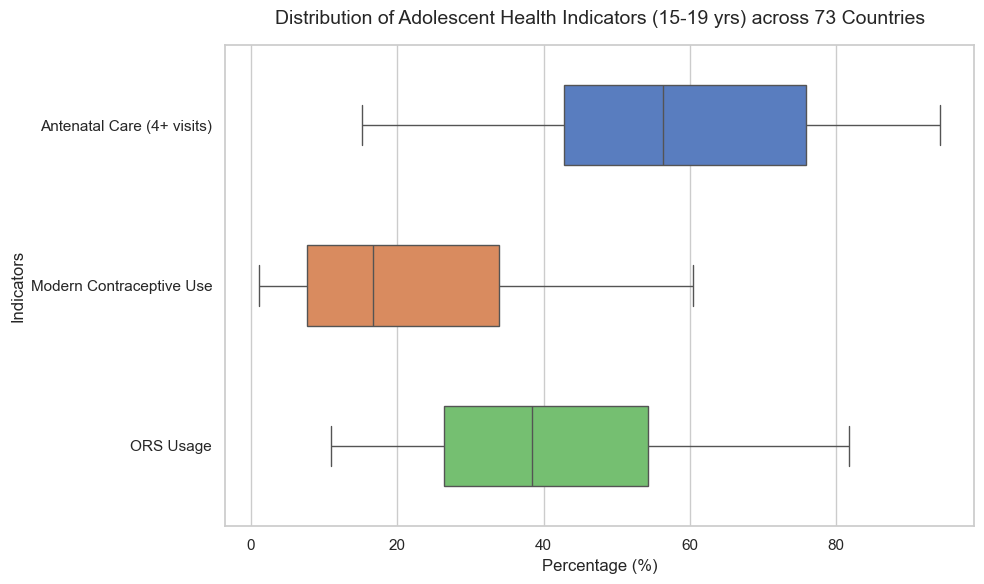

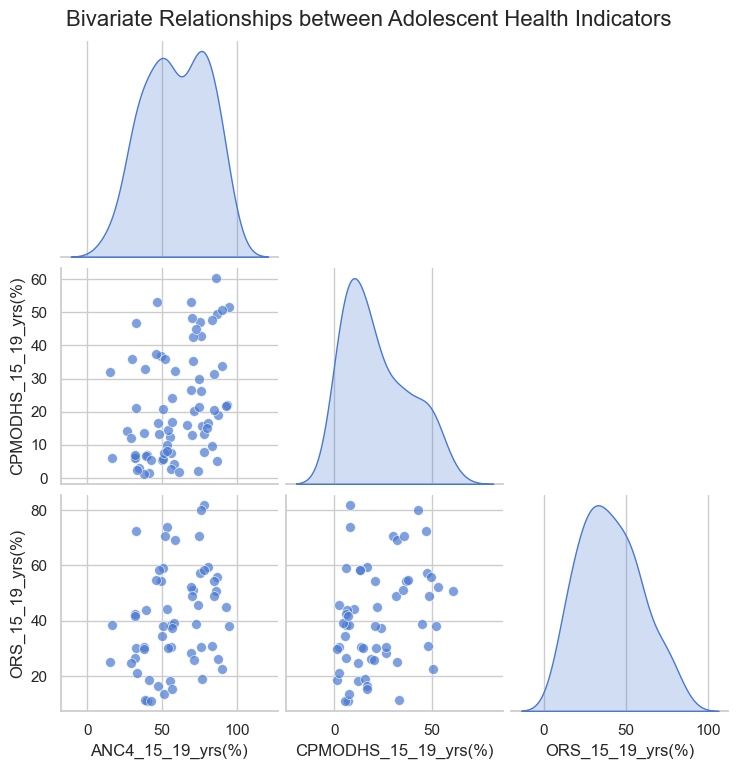

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional academic-style visualization theme
sns.set_theme(style="whitegrid", palette="muted")

# Extract the three indicator columns for plotting
cols_to_plot = ['ANC4_15_19_yrs(%)', 'CPMODHS_15_19_yrs(%)', 'ORS_15_19_yrs(%)']

# 1. Boxplot — Distribution of indicators across countries
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_adolescent_wide[cols_to_plot], orient="h", width=0.5)
plt.title('Distribution of Adolescent Health Indicators (15-19 yrs) across 73 Countries', fontsize=14, pad=15)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Indicators', fontsize=12)
plt.tight_layout()
# Use clearer labels
custom_labels = ['Antenatal Care (4+ visits)', 'Modern Contraceptive Use', 'ORS Usage']
plt.yticks(ticks=[0, 1, 2], labels=custom_labels, fontsize=11)
plt.show()

# 2. Pairplot — Scatter plot matrix with KDE on the diagonal
g = sns.pairplot(df_adolescent_wide[cols_to_plot], diag_kind='kde', corner=True, plot_kws={'alpha':0.7, 's':50})
g.fig.suptitle('Bivariate Relationships between Adolescent Health Indicators', fontsize=16, y=1.02)
plt.show()

Figure 1: Distribution Characteristics of Three Core Health Indicators Among Adolescents Aged 15-19 (Boxplot)
This figure illustrates the cross-national distribution of three health indicators—Antenatal Care 4+ visits (ANC4), Modern Contraceptive Use (CPMODHS), and Oral Rehydration Salts usage (ORS)—among adolescents aged 15-19 across 73 countries. The results indicate that modern contraceptive use is generally low and right-skewed across most nations. In contrast, the usage of ORS exhibits the most substantial cross-national disparity, showing a high degree of data dispersion.

Figure 2: Pairwise Correlation and Probability Density of Three Adolescent Health Indicators (Scatter Plot Matrix)
This matrix explores the pairwise correlations and univariate distributions of the three health indicators (ANC4, CPMODHS, ORS) using scatter plots and Kernel Density Estimation (KDE). The diagonal density plots further validate the concentration of low values in CPMODHS. The off-diagonal scatter plots reveal a lack of strong linear correlation among the variables, with only a very weak positive trend observed between ANC4 and CPMODHS, suggesting a limited association between maternal care systems and reproductive health interventions.